# Разведка данных

Задача — отличить трафик известных сервисов сбора данных от трафика, отнесённого к человеческому.
Единица наблюдения — куки с суточным окном, а не отдельное событие.

Сначала проверяю данные и окна. Затем смотрю, чем различается поведение классов.
Для сравнений с `target` использую 6–10 апреля — обучающую часть первого разбиения.
Тестовые метки не нужны.

In [1]:
from pathlib import Path
import sys
import platform

import numpy as np
import pandas as pd

ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"
OUTPUTS = ROOT / "outputs"
SEED = 2026
THREADS = 4

from features import META, MISSING, prepare_events, get_event_names, make_features

print("Python", platform.python_version())

import matplotlib.pyplot as plt
from IPython.display import display
from features import EVENT_COLUMNS, canonical_platform, ua_family

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 30)

Python 3.13.5


## Размер выборок и разметка

In [2]:
def read_meta(filename):
    frame = pd.read_csv(DATA / filename, dtype={"cookie_id": str})
    for column in META[1:]:
        frame[column] = pd.to_datetime(frame[column], utc=True)
    return frame

train = read_meta("train.csv")
train = train.sort_values(["window_start_ts", "cookie_id"], kind="stable").reset_index(drop=True)
test = read_meta("test.csv")
raw_events = pd.read_csv(DATA / "events.csv.gz", dtype=str)
meta = pd.concat([train[META], test[META]], ignore_index=True)

pd.Series({"train": len(train), "test": len(test), "events": len(raw_events)}, name="rows")

train      11091
test        4909
events    328905
Name: rows, dtype: int64

In [3]:
train.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_0010ec3874fb5378,2025-12-24 14:30:54+00:00,2026-04-06 00:00:00+00:00,2026-04-07 00:00:00+00:00,0
1,ck_008c04d82d0561f5,2026-01-02 23:57:46+00:00,2026-04-06 00:00:00+00:00,2026-04-07 00:00:00+00:00,0
2,ck_00c4ffd7008dcb87,2026-04-04 14:32:50+00:00,2026-04-06 00:00:00+00:00,2026-04-07 00:00:00+00:00,0
3,ck_00f708f4ee157b65,2026-01-28 02:24:44+00:00,2026-04-06 00:00:00+00:00,2026-04-07 00:00:00+00:00,0
4,ck_01398e0204df2412,2026-02-06 15:40:12+00:00,2026-04-06 00:00:00+00:00,2026-04-07 00:00:00+00:00,0


In [4]:
overview = pd.DataFrame({
    "Куки": [len(train), len(test)],
    "Начало периода": [train.window_start_ts.min(), test.window_start_ts.min()],
    "Конец периода": [train.window_end_ts.max(), test.window_end_ts.max()],
}, index=["train", "test"])
display(overview)

classes = train.target.value_counts().sort_index().to_frame("Куки")
classes["Доля"] = classes["Куки"] / len(train)
classes.index = ["0 — человеческий трафик", "1 — известные сервисы"]
classes

,Куки,Начало периода,Конец периода
train,11091,2026-04-06 00:00:00+00:00,2026-04-20 00:00:00+00:00
test,4909,2026-04-20 00:00:00+00:00,2026-04-27 00:00:00+00:00


,Куки,Доля
0 — человеческий трафик,10192,0.918943
1 — известные сервисы,899,0.081057


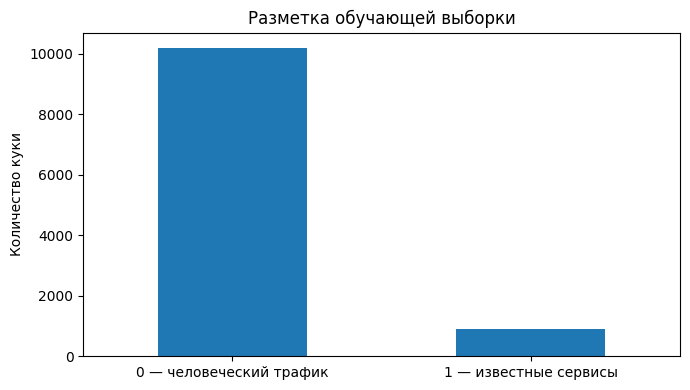

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
classes["Куки"].plot.bar(ax=ax, rot=0)
ax.set_ylabel("Количество куки")
ax.set_title("Разметка обучающей выборки")
fig.tight_layout()
plt.show()

В train 899 положительных куки из 11 091, то есть около 8.1%.
Поэтому accuracy здесь малоинформативна. Основная метрика задачи — precision при recall не ниже 70%.

## Окна наблюдения

In [6]:
assert train.cookie_id.notna().all() and train.cookie_id.is_unique
assert test.cookie_id.notna().all() and test.cookie_id.is_unique
assert set(train.cookie_id).isdisjoint(test.cookie_id)
assert train.target.notna().all() and set(train.target) == {0, 1}
assert "target" not in test
assert meta[META[1:]].notna().all().all()
assert (meta.window_end_ts - meta.window_start_ts).dt.total_seconds().eq(86400).all()
assert (meta.cookie_created_at < meta.window_end_ts).all()
assert train.window_end_ts.max() <= test.window_start_ts.min()

print("Идентификаторы, разметка и окна наблюдения в порядке")

Идентификаторы, разметка и окна наблюдения в порядке


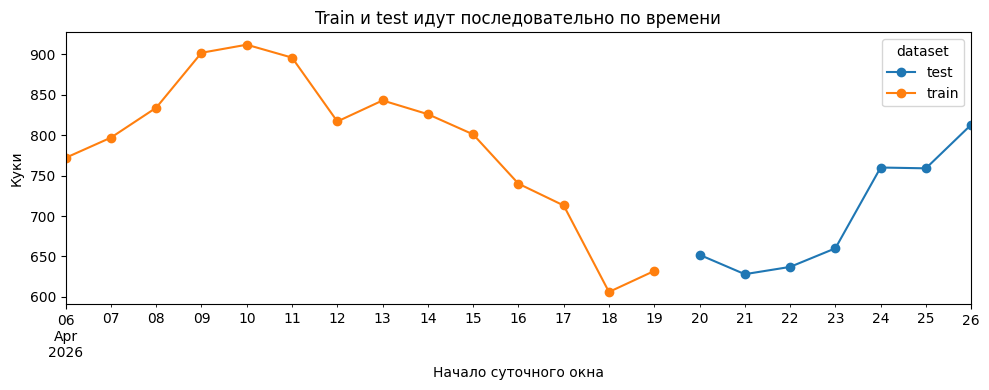

In [7]:
daily = pd.concat([
    train.assign(dataset="train")[["window_start_ts", "dataset"]],
    test.assign(dataset="test")[["window_start_ts", "dataset"]],
])
daily["day"] = daily.window_start_ts.dt.floor("D")
daily = daily.groupby(["day", "dataset"]).size().unstack("dataset")

fig, ax = plt.subplots(figsize=(10, 4))
daily.plot(ax=ax, marker="o")
ax.set_ylabel("Куки")
ax.set_xlabel("Начало суточного окна")
ax.set_title("Train и test идут последовательно по времени")
fig.tight_layout()
plt.show()

Все окна длятся 24 часа. Train охватывает начала окон с 6 по 19 апреля,
а test — с 20 по 26 апреля. Куки между выборками не пересекаются.
Для проверки модели тоже использую разбиение по времени.

## События вне окна, порядок строк и дубликаты

In [8]:
event_times = pd.to_datetime(raw_events.event_ts, utc=True, format="mixed", errors="coerce")
assert event_times.notna().all()
assert raw_events.cookie_id.isin(meta.cookie_id).all()

joined = raw_events.copy()
joined["event_ts"] = event_times
joined = joined.merge(meta[META], on="cookie_id", how="inner")
inside = joined.event_ts.ge(joined.window_start_ts) & joined.event_ts.lt(joined.window_end_ts)
in_window = joined.loc[inside]
duplicate_rows = in_window.duplicated(EVENT_COLUMNS)

clean = prepare_events(raw_events, meta)
raw_in_window = prepare_events(raw_events, meta, deduplicate=False)

pd.Series({
    "Всего событий": len(joined),
    "Раньше окна": int((joined.event_ts < joined.window_start_ts).sum()),
    "На границе конца окна или позже": int((joined.event_ts >= joined.window_end_ts).sum()),
    "Внутри окна до очистки": len(in_window),
    "Точные дубликаты внутри окна": int(duplicate_rows.sum()),
    "После очистки": len(clean),
    "Куки без событий в окне": int((~meta.cookie_id.isin(clean.cookie_id)).sum()),
    "Куки с нарушенным порядком событий в исходном файле": int(
        joined.groupby("cookie_id").event_ts.apply(lambda s: not s.is_monotonic_increasing).sum()
    ),
})

Всего событий                                          328905
Раньше окна                                                 0
На границе конца окна или позже                         40779
Внутри окна до очистки                                 288126
Точные дубликаты внутри окна                             4293
После очистки                                          283833
Куки без событий в окне                                     0
Куки с нарушенным порядком событий в исходном файле     15441
dtype: int64

In [9]:
assert clean.event_ts.ge(clean.window_start_ts).all()
assert clean.event_ts.lt(clean.window_end_ts).all()
assert not clean.duplicated(EVENT_COLUMNS).any()
assert (clean.event_ts >= clean.cookie_created_at).all()
assert clean.groupby("cookie_id").event_ts.apply(lambda s: s.is_monotonic_increasing).all()
print("Признаки будут считаться по отсортированным событиям внутри окна")

Признаки будут считаться по отсортированным событиям внутри окна


Из 328 905 строк 40 779 находятся вне окна. Внутри окна есть 4 293 точных дубликата.
После фильтрации и удаления дублей остаётся 283 833 события.
Дубли считаю повторной записью события. Это допущение; baseline ниже сравнивается и с очисткой, и без неё.
Событие ровно в `window_end_ts` уже не включается.

## Типы событий и пропуски

In [10]:
event_counts = clean.event_name.value_counts().to_frame("События")
event_counts["Доля"] = event_counts["События"] / len(clean)
display(event_counts)

assert clean.groupby("eid").event_name.nunique().max() == 1
assert clean.groupby("event_name").eid.nunique().max() == 1

,События,Доля
event_name,,
item_view,106448,0.375037
search_results_view,88479,0.311729
photo_swipe,32570,0.114751
favorite_add,17012,0.059937
seller_page_view,15343,0.054056
contact_phone_show,10145,0.035743
login,5579,0.019656
contact_chat_open,5479,0.019304
contact_message_sent,2778,0.009787


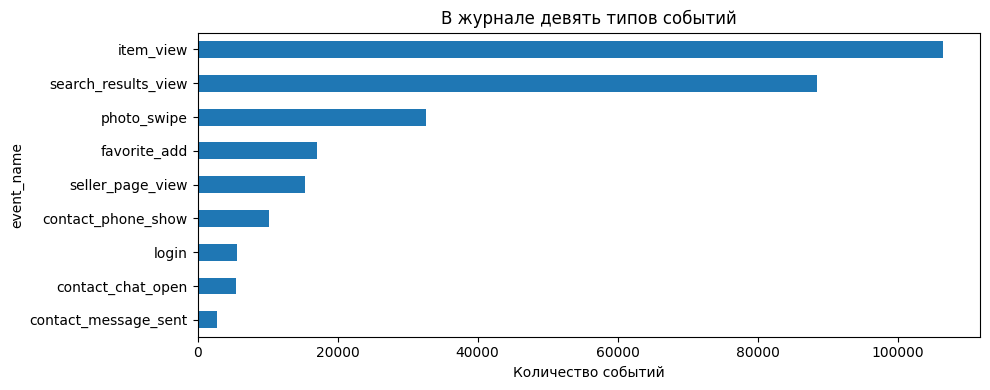

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
event_counts["События"].sort_values().plot.barh(ax=ax)
ax.set_xlabel("Количество событий")
ax.set_title("В журнале девять типов событий")
fig.tight_layout()
plt.show()

In [12]:
fields = ["item_id", "item_category", "item_location", "seller_type",
          "search_query", "search_page", "pointer_x", "pointer_y"]
missing = clean[fields].isna() | clean[fields].eq(MISSING)
display(missing.mean().rename("Доля пропусков").to_frame())

missing_by_event = missing.groupby(clean.event_name).mean().reindex(event_counts.index)
missing_by_event.round(3)

,Доля пропусков
item_id,0.331385
item_category,0.078085
item_location,0.049645
seller_type,0.39142
search_query,0.688271
search_page,0.688271
pointer_x,0.66791
pointer_y,0.66791


,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
event_name,,,,,,,,
item_view,0.0,0.06,0.03,0.09,1.0,1.0,0.674,0.674
search_results_view,1.0,0.06,0.031,1.0,0.0,0.0,0.669,0.669
photo_swipe,0.0,0.059,0.032,0.088,1.0,1.0,0.657,0.657
favorite_add,0.0,0.062,0.028,0.091,1.0,1.0,0.651,0.651
seller_page_view,0.0,0.058,0.032,0.089,1.0,1.0,0.663,0.663
contact_phone_show,0.0,0.059,0.029,0.095,1.0,1.0,0.671,0.671
login,1.0,1.0,1.0,1.0,1.0,1.0,0.647,0.647
contact_chat_open,0.0,0.058,0.031,0.085,1.0,1.0,0.686,0.686
contact_message_sent,0.0,0.06,0.028,0.089,1.0,1.0,0.675,0.675


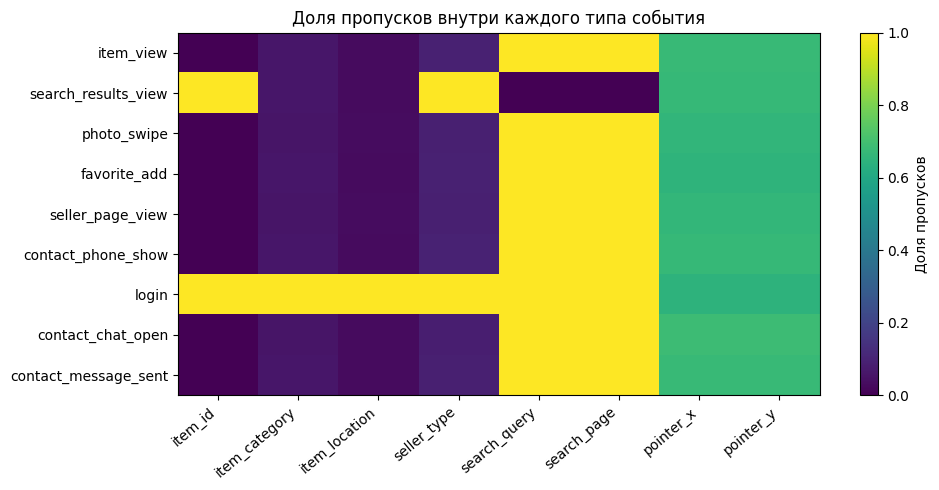

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(missing_by_event.to_numpy(dtype=float), vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(fields)), fields, rotation=40, ha="right")
ax.set_yticks(range(len(missing_by_event)), missing_by_event.index)
ax.set_title("Доля пропусков внутри каждого типа события")
fig.colorbar(image, ax=ax, label="Доля пропусков")
fig.tight_layout()
plt.show()

У поиска нет `item_id`, а у просмотров объявления нет `search_query`.
Это ожидаемые пропуски: поля заполняются в зависимости от события.
Не заменяю их нулями и считаю условные агрегаты отдельно для поиска и просмотров.
Капча есть в описании задачи, но в этом файле таких событий нет.

## Платформа и User-Agent

In [14]:
platforms = clean[["cookie_id", "platform"]].copy()
platforms["normalized"] = platforms.platform.map(canonical_platform)
platform_table = platforms.groupby(["normalized", "platform"]).size().rename("События")
display(platform_table.to_frame())

platform_diversity = platforms.groupby("cookie_id").agg(
    raw=("platform", "nunique"), normalized=("normalized", "nunique")
)
display(platform_diversity.value_counts().rename("Куки").to_frame())
assert platform_diversity.normalized.eq(1).all()

События
normalized platform         
android    ANDROID     37013
           Android     36802
           android     36741
ios        IOS          3589
           iOS          3593
           ios          3600
           iphone       3597
web        WEB         39740
           Web         39689
           desktop     40159
           web         39310

,,Куки
raw,normalized,
3,1,7051
4,1,6578
2,1,1739
1,1,632


`web`, `Web`, `WEB` и `desktop` — разные записи одной платформы; аналогичная ситуация с Android и iOS.
После нормализации у каждой куки остаётся одна платформа.
Без этого исправления разнообразие написаний можно принять за смену устройств.

In [15]:
eda_train = train.loc[train.window_start_ts < pd.Timestamp("2026-04-11", tz="UTC")].copy()
events = clean.loc[clean.cookie_id.isin(eda_train.cookie_id)].copy()

ua_lookup = {value: ua_family(value) for value in events.user_agent.unique()}
events["automation"] = events.user_agent.map({value: parsed[2] for value, parsed in ua_lookup.items()})
ua_by_cookie = events.groupby("cookie_id").automation.max().to_frame("automation")
ua_by_cookie = ua_by_cookie.join(eda_train.set_index("cookie_id").target)
ua_summary = ua_by_cookie.groupby("automation").target.agg(["count", "sum", "mean"])
ua_summary.columns = ["Куки", "Положительные куки", "Доля положительных"]
ua_summary

,Куки,Положительные куки,Доля положительных
automation,,,
0.0,4060,304,0.074877
1.0,157,41,0.261146


Маркер автоматизации встречается и в отрицательном классе.
В первом обучающем периоде он есть у 157 куки, из них 41 положительная.
Поэтому `HeadlessChrome` или `python-requests` — дополнительный сигнал, а не готовая разметка.
Полные строки User-Agent не использую: извлекаю семейства браузера и ОС и долю событий с маркером автоматизации.

## Поведение внутри окна

In [16]:
groups = events.groupby("cookie_id", sort=False)
profile = eda_train.set_index("cookie_id")[["target"]].copy()
profile["n_events"] = groups.size()
profile["age_days"] = (
    eda_train.set_index("cookie_id").window_end_ts
    - eda_train.set_index("cookie_id").cookie_created_at
).dt.total_seconds() / 86400

observed_items = events.loc[events.item_id.ne(MISSING)].groupby("cookie_id").item_id
observed_categories = events.loc[events.item_category.ne(MISSING)].groupby("cookie_id").item_category
profile["n_items"] = observed_items.nunique()
profile["category_unique_share"] = observed_categories.nunique() / observed_categories.count()

events["gap"] = groups.event_ts.diff().dt.total_seconds()
within = events.loc[events.gap.gt(0) & events.gap.le(300)]
profile["within300_median"] = within.groupby("cookie_id").gap.median()

pointer = events.loc[events.pointer_x.notna() & events.pointer_y.notna()]
pointer_groups = pointer.groupby("cookie_id")
span = pointer_groups[["pointer_x", "pointer_y"]].max() - pointer_groups[["pointer_x", "pointer_y"]].min()
profile["pointer_axis_ratio"] = (span.min(axis=1) / span.max(axis=1)).where(pointer_groups.size().ge(3))
profile["pointer_unique_y_share"] = (pointer_groups.pointer_y.nunique() / pointer_groups.size()).where(pointer_groups.size().ge(3))

profile.groupby("target").median().round(3)

,n_events,age_days,n_items,category_unique_share,within300_median,pointer_axis_ratio,pointer_unique_y_share
target,,,,,,,
0,11.0,62.234,6.0,0.200,46.0,0.558,1.000
1,20.0,27.214,10.0,0.095,20.5,0.807,0.947


In [17]:
clean.groupby("cookie_id").size().describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).to_frame("События на куки")

,События на куки
count,16000.000000
mean,17.739563
std,17.729242
min,1.000000
25%,6.000000
50%,12.000000
75%,23.000000
90%,39.000000
99%,87.000000
max,187.000000


В полной выборке медиана — 12 событий на куки, максимум — 187.
По короткой истории нельзя надёжно оценить сложный паттерн, поэтому статистики при недостатке наблюдений оставляю пропусками.
Ниже каждое наблюдение на графике — куки, а не событие. Так активные пользователи не получают больший вес.

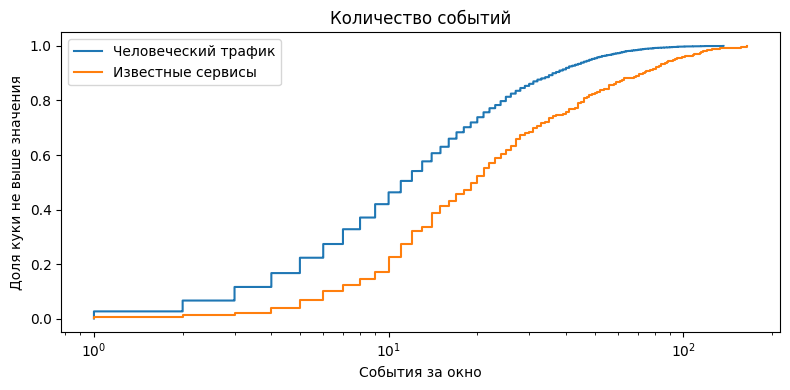

In [18]:
def plot_ecdf(column, title, xlabel, log_x=False):
    fig, ax = plt.subplots(figsize=(8, 4))
    for target, label in [(0, "Человеческий трафик"), (1, "Известные сервисы")]:
        values = np.sort(profile.loc[profile.target.eq(target), column].dropna().to_numpy())
        ax.step(values, np.arange(1, len(values) + 1) / len(values), where="post", label=label)
    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Доля куки не выше значения")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()

plot_ecdf("n_events", "Количество событий", "События за окно", log_x=True)

У положительного класса событий в среднем больше, но диапазоны сильно перекрываются.
Одного порога по количеству действий недостаточно — это видно и по слабому RF-baseline на двух счётчиках.

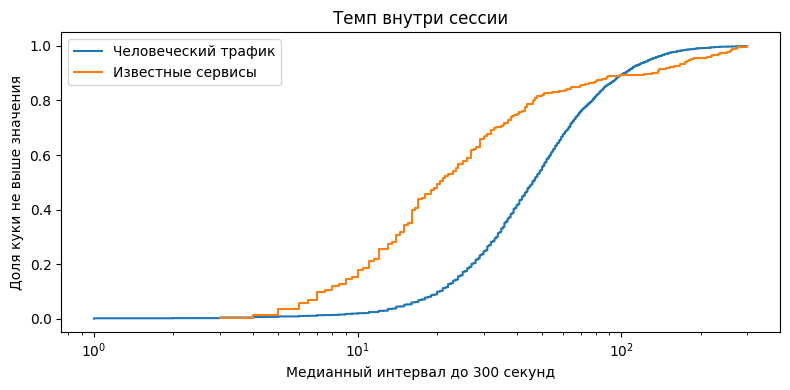

In [19]:
plot_ecdf("within300_median", "Темп внутри сессии", "Медианный интервал до 300 секунд", log_x=True)

В первом обучающем периоде медианы внутрисессионных интервалов по кукам — 46 секунд у отрицательного класса
и 20.5 секунды у положительного. Длинные перерывы считаю отдельно: иначе они смешиваются с темпом действий.
Помимо скорости, в признаках есть разброс и регулярность интервалов.

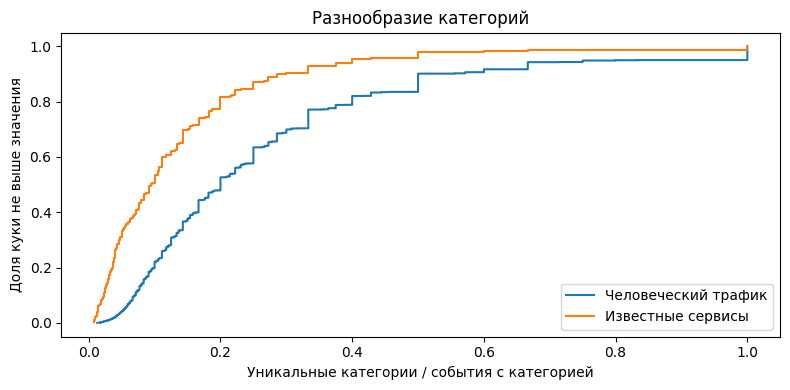

In [20]:
plot_ecdf("category_unique_share", "Разнообразие категорий", "Уникальные категории / события с категорией")

У положительного класса чаще повторяются одни и те же категории.
Доля уникальных значений зависит от длины истории, поэтому в модели она используется вместе с объёмом активности,
энтропией и другими оценками концентрации.

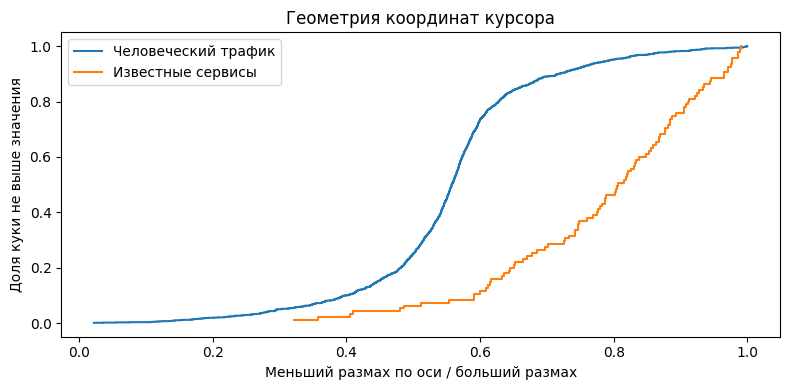

In [21]:
plot_ecdf("pointer_axis_ratio", "Геометрия координат курсора", "Меньший размах по оси / больший размах")

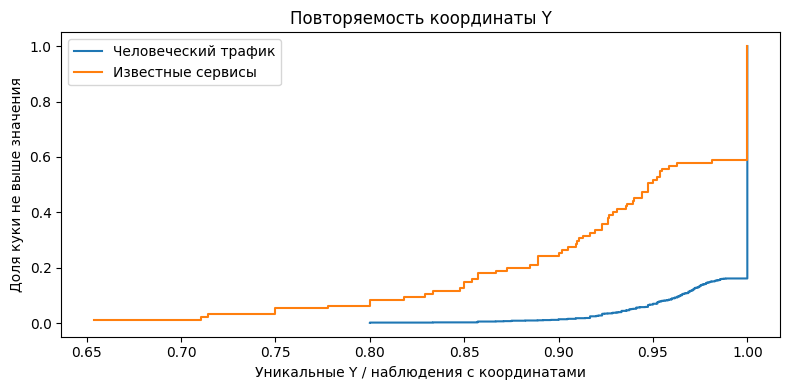

In [22]:
plot_ecdf("pointer_unique_y_share", "Повторяемость координаты Y", "Уникальные Y / наблюдения с координатами")

Координаты дают дополнительный сигнал: различаются соотношение размахов и повторяемость Y.
Это не полная траектория мыши — координаты записаны только в моменты событий.
Поэтому не делаю выводов о физике движения и не использую абсолютные пиксельные значения как признаки.

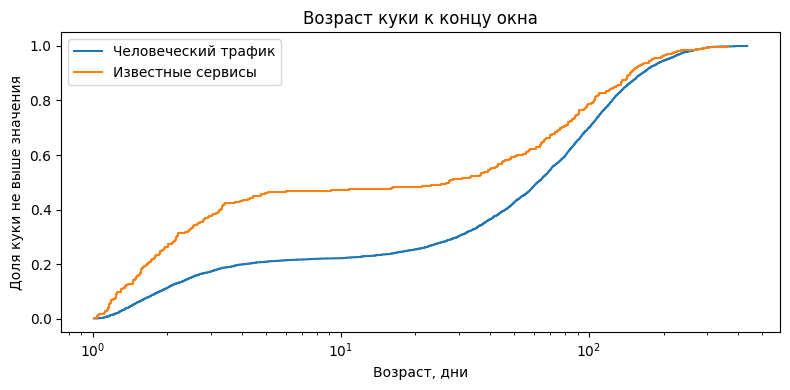

In [23]:
plot_ecdf("age_days", "Возраст куки к концу окна", "Возраст, дни", log_x=True)

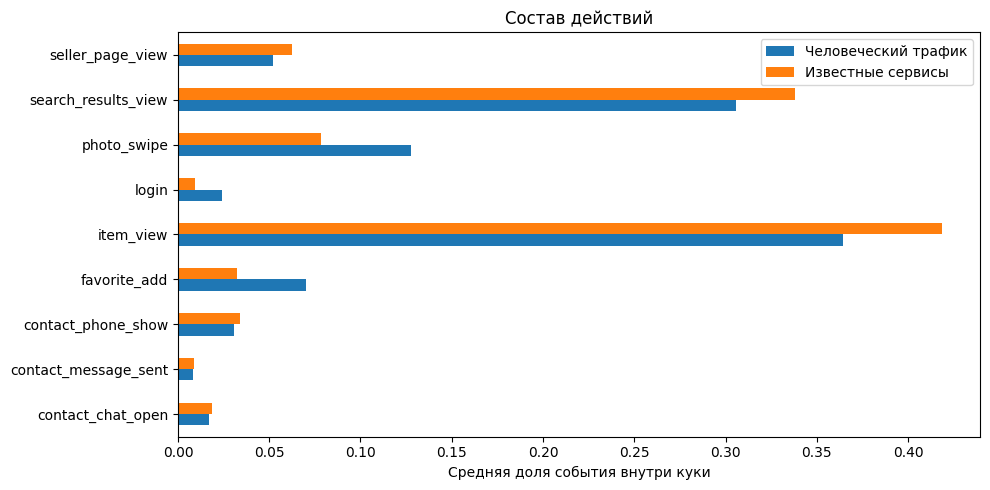

In [24]:
actions = pd.crosstab(events.cookie_id, events.event_name)
action_shares = actions.div(actions.sum(axis=1), axis=0)
action_shares = action_shares.join(profile.target)
mean_actions = action_shares.groupby("target").mean().T
mean_actions.columns = ["Человеческий трафик", "Известные сервисы"]

fig, ax = plt.subplots(figsize=(10, 5))
mean_actions.plot.barh(ax=ax)
ax.set_xlabel("Средняя доля события внутри куки")
ax.set_title("Состав действий")
fig.tight_layout()
plt.show()

## Проверка расчёта признаков

Проверяю границы окна, отсутствие влияния будущих событий и независимость агрегатов от порядка строк.
Эти проверки находятся здесь, а в `features.py` остаётся сам расчёт.

In [25]:
small_meta = train.iloc[:8][META].copy()
small_events = clean.loc[clean.cookie_id.isin(small_meta.cookie_id)]
event_names = get_event_names(eda_train, clean)
first = make_features(small_meta, small_events, event_names, n_jobs=1)
shuffled = make_features(small_meta, small_events.sample(frac=1, random_state=SEED), event_names, n_jobs=1)
pd.testing.assert_frame_equal(first, shuffled)

with_labels = make_features(small_meta.assign(target=1), small_events, event_names, n_jobs=1)
pd.testing.assert_frame_equal(first, with_labels)

empty = make_features(small_meta, small_events.iloc[:0], event_names, n_jobs=1)
assert empty.n_events.eq(0).all()
assert empty.gap_mean.isna().all()
assert len(empty) == len(small_meta)
print("Порядок строк и target не влияют на признаки; куки без событий сохраняются")

Порядок строк и target не влияют на признаки; куки без событий сохраняются


/mnt/data/avito-antibot/features.py:639: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['__MISSING__' '__MISSING__' '__MISSING__' '__MISSING__' '__MISSING__'
 '__MISSING__' '__MISSING__' '__MISSING__']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  rows.loc[absent] = pd.DataFrame([default] * len(absent), index=absent)
/mnt/data/avito-antibot/features.py:639: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['__MISSING__' '__MISSING__' '__MISSING__' '__MISSING__' '__MISSING__'
 '__MISSING__' '__MISSING__' '__MISSING__']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  rows.loc[absent] = pd.DataFrame([default] * len(absent), index=absent)
/mnt/data/avito-antibot/features.py:639: FutureWarning: Setting an item of incompatible dtype is depreca

In [26]:
one = train.iloc[:1][META]
cookie = one.cookie_id.iloc[0]
example = raw_events.loc[raw_events.cookie_id.eq(cookie)].iloc[:1]
edge_events = pd.concat([example] * 4, ignore_index=True)
start = one.window_start_ts.iloc[0]
end = one.window_end_ts.iloc[0]
edge_events["event_ts"] = [start - pd.Timedelta(seconds=1), start, end - pd.Timedelta(seconds=1), end]
filtered = prepare_events(edge_events, one)
assert filtered.event_ts.tolist() == [start, end - pd.Timedelta(seconds=1)]

original = raw_events.loc[raw_events.cookie_id.isin(small_meta.cookie_id)].copy()
future = original.iloc[:1].copy()
future["event_ts"] = small_meta.window_end_ts.max() + pd.Timedelta(days=1)
before = prepare_events(original, small_meta)
after = prepare_events(pd.concat([original, future], ignore_index=True), small_meta)
pd.testing.assert_frame_equal(before, after)

repeated = prepare_events(pd.concat([original, original], ignore_index=True), small_meta)
pd.testing.assert_frame_equal(before, repeated)
print("Границы окна, будущие события и точные дубликаты обработаны правильно")

Границы окна, будущие события и точные дубликаты обработаны правильно


## Что беру в модель

Счётчики и доли действий дополняю интервалами, сессиями, разнообразием интересов,
глубиной поиска, относительными координатными признаками и нормализованным браузерным контекстом.
Сырые идентификаторы, тексты запросов и абсолютные даты оставляю только для объединения и агрегирования.

Важные ограничения: разметка описывает известные сервисы, а не всех ботов;
короткие истории менее информативны; изменение трекинга координат может ухудшить перенос модели.
Сравнение моделей и итоговый выбор — в `02_experiments.ipynb`.